In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd

In [3]:
df = pd.read_csv("output/B_1T_500_15000_500_pion.csv")
df.head()

,Momentum (MeV/c),Transverse Momentum (MeV/c),Pseudorapidity,Momentum Accuracy (%),DCA (mm)
0,4500,4302.825301,0.301591,0.147792,8.446593e+06
1,14000,8894.680178,-1.025847,0.119730,1.741442e+07
2,2000,586.428073,-1.897778,31.668166,8.970634e+05
3,4000,3954.725788,-0.151171,0.304742,7.728460e+06
4,1500,1083.042447,-0.851522,0.763632,2.107329e+06


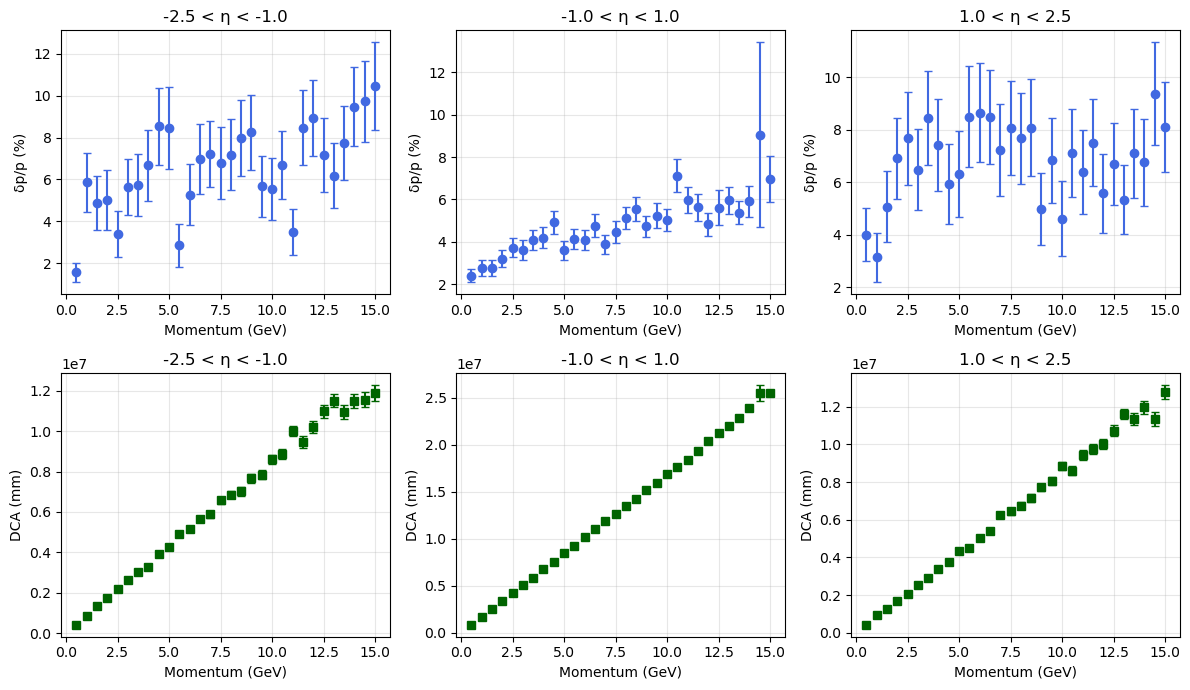

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

eta_bins = [
    (-2.5, -1.0),
    (-1.0,  1.0),
    ( 1.0,  2.5),
]

for i, (eta_lo, eta_hi) in enumerate(eta_bins):
    df_eta = df[(df["Pseudorapidity"] >= eta_lo) &
                (df["Pseudorapidity"] < eta_hi)]
    
    momentum_points = sorted(df_eta["Momentum (MeV/c)"].unique())

    p_Gev = []
    p_accuracy = []
    p_accuracy_err = []
    DCA = []
    DCA_err = []

    for p in momentum_points:
        subset = df_eta[df_eta["Momentum (MeV/c)"] == p]

        p_Gev.append(p / 1000.0) 
        p_accuracy.append(subset["Momentum Accuracy (%)"].mean())
        p_accuracy_err.append(subset["Momentum Accuracy (%)"].std() / np.sqrt(len(subset)))
        DCA.append(subset["DCA (mm)"].mean())
        DCA_err.append(subset["DCA (mm)"].std() / np.sqrt(len(subset)))
    
    ax = axes[0, i]
    ax.errorbar(p_Gev, p_accuracy, yerr=p_accuracy_err, fmt='o', color='royalblue', capsize=3)
    ax.set_title(f"{eta_lo} < η < {eta_hi}")
    ax.set_xlabel("Momentum (GeV)")
    ax.set_ylabel("δp/p (%)")
    ax.grid(alpha=0.3)

    ax = axes[1, i]
    ax.errorbar(p_Gev, DCA, yerr=DCA_err, fmt='s', color='darkgreen', capsize=3)
    ax.set_title(f"{eta_lo} < η < {eta_hi}")
    ax.set_xlabel("Momentum (GeV)")
    ax.set_ylabel("DCA (mm)")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

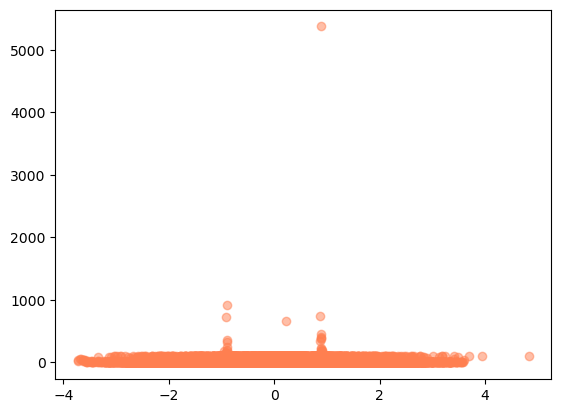

In [5]:
plt.scatter(df["Pseudorapidity"], df["Momentum Accuracy (%)"], alpha=0.5, color='coral')